In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)


# Preprocessing

In [2]:
begin = "1990-01-01"
end = "2026-01-01"

In [3]:
prop = pd.read_csv("./Data/Property.csv",low_memory=False)


prop = prop.transpose()
prop = prop[1:]

prop = prop.reset_index()

prop.columns = ["Date","Property_Crime"]




violent = pd.read_csv("./Data/Violent.csv")

violent = violent.transpose()
violent = violent[1:]

violent = violent.reset_index()

violent.columns = ["Date","Violent_Crime"]


crime = pd.merge(prop, violent, on='Date', how='inner')
unemployment = pd.read_csv("./Data/unemployment_historical.csv")


In [4]:
import pandas as pd

crime["Date"] = pd.to_datetime(crime["Date"], errors="coerce")

crimets = crime.loc[
    (crime["Date"] >= "1990-01-01") &
    (crime["Date"] <  "2026-01-01")
].copy()

crime = crimets.sort_values("Date")

crime.head()


/var/folders/k6/jt73vds53h50yfyvznvj62nw0000gn/T/ipykernel_1967/1504564145.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crime["Date"] = pd.to_datetime(crime["Date"], errors="coerce")


,Date,Property_Crime,Violent_Crime
60,1990-01-01,8829,2385
61,1990-02-01,6991,1903
62,1990-03-01,7860,2116
63,1990-04-01,7648,2105
64,1990-05-01,7281,2387


In [5]:
unemployment

,Series ID,Year,Period,Label,Value
0,LAUCN261630000000003,1990,M01,1990 Jan,9.1
1,LAUCN261630000000003,1990,M02,1990 Feb,9.2
2,LAUCN261630000000003,1990,M03,1990 Mar,8.9
3,LAUCN261630000000003,1990,M04,1990 Apr,8.4
4,LAUCN261630000000003,1990,M05,1990 May,8.6
...,...,...,...,...,...
427,LAUCN261630000000003,2025,M08,2025 Aug,5.3
428,LAUCN261630000000003,2025,M09,2025 Sep,5.9
429,LAUCN261630000000003,2025,M10,2025 Oct,-
430,LAUCN261630000000003,2025,M11,2025 Nov,6.2


In [6]:
unemployment["Date"] = pd.to_datetime(unemployment["Label"], format="%Y %b")

unemployment = unemployment.loc[
    (unemployment["Date"] >= begin) &
    (unemployment["Date"] <  end)
].copy()

unemployment['Value'] = pd.to_numeric(unemployment['Value'], errors='coerce')





In [7]:
unemployment.head()

,Series ID,Year,Period,Label,Value,Date
0,LAUCN261630000000003,1990,M01,1990 Jan,9.1,1990-01-01
1,LAUCN261630000000003,1990,M02,1990 Feb,9.2,1990-02-01
2,LAUCN261630000000003,1990,M03,1990 Mar,8.9,1990-03-01
3,LAUCN261630000000003,1990,M04,1990 Apr,8.4,1990-04-01
4,LAUCN261630000000003,1990,M05,1990 May,8.6,1990-05-01


In [8]:
crime_nas = crime['Property_Crime'].isna().sum()
crime_nas = crime['Violent_Crime'].isna().sum()

crime_nas

np.int64(0)

In [9]:
unemployment_nas = unemployment['Value'].isna().sum()

nas = unemployment[unemployment.isna().any(axis=1)]

unemployment_nas

print(nas)

                Series ID  Year Period     Label  Value       Date
429  LAUCN261630000000003  2025    M10  2025 Oct    NaN 2025-10-01


In [10]:
unemployment['Value'] = unemployment['Value'].astype(float).interpolate(method='linear')

unemployment_nas = unemployment['Value'].isna().sum()
unemployment_nas

np.int64(0)

# Covid Encoding 

In [11]:
# unemployment

unemployment["Covid"] = 0  # default = pre-COVID

unemployment.loc[unemployment["Date"] >= "2020-03-01", "Covid"] = 1
unemployment.loc[unemployment["Date"] >= "2021-07-01", "Covid"] = 2


# crime
crime["Covid"] = 0  # default = pre-COVID

crime.loc[crime["Date"] >= "2020-03-01", "Covid"] = 1
crime.loc[crime["Date"] >= "2022-06-01", "Covid"] = 2

In [12]:
crime["Value"] = crime["Property_Crime"] + crime["Violent_Crime"]

# EDA

In [13]:
crime

,Date,Property_Crime,Violent_Crime,Covid,Value
60,1990-01-01,8829,2385,0,11214
61,1990-02-01,6991,1903,0,8894
62,1990-03-01,7860,2116,0,9976
63,1990-04-01,7648,2105,0,9753
64,1990-05-01,7281,2387,0,9668
...,...,...,...,...,...
487,2025-08-01,2456,1058,2,3514
488,2025-09-01,2065,920,2,2985
489,2025-10-01,2238,866,2,3104
490,2025-11-01,1986,814,2,2800


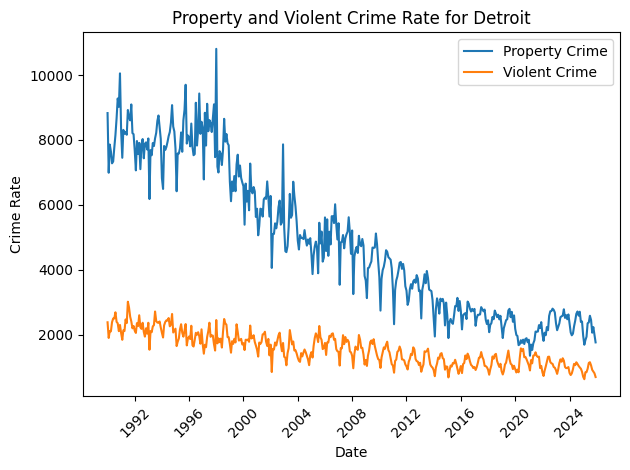

In [14]:
plt.figure()

plt.plot(crime['Date'], crime['Property_Crime'], label='Property Crime')
plt.plot(crime['Date'], crime['Violent_Crime'], label='Violent Crime')
#plt.plot(crime['Date'], crime['Value'], label='All Crime')


plt.xlabel("Date")
plt.ylabel("Crime Rate")
plt.title("Property and Violent Crime Rate for Detroit")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("PropAndViolentCrime.jpg")
plt.show()

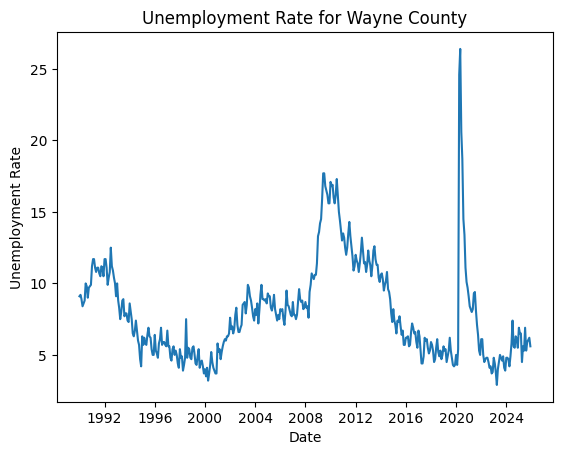

In [15]:
plt.figure()
plt.plot(unemployment['Date'],unemployment['Value'])
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.title("Unemployment Rate for Wayne County")
plt.savefig("UnemploymentWayneCounty.jpg")

plt.show()

# Initial ACF and PACF

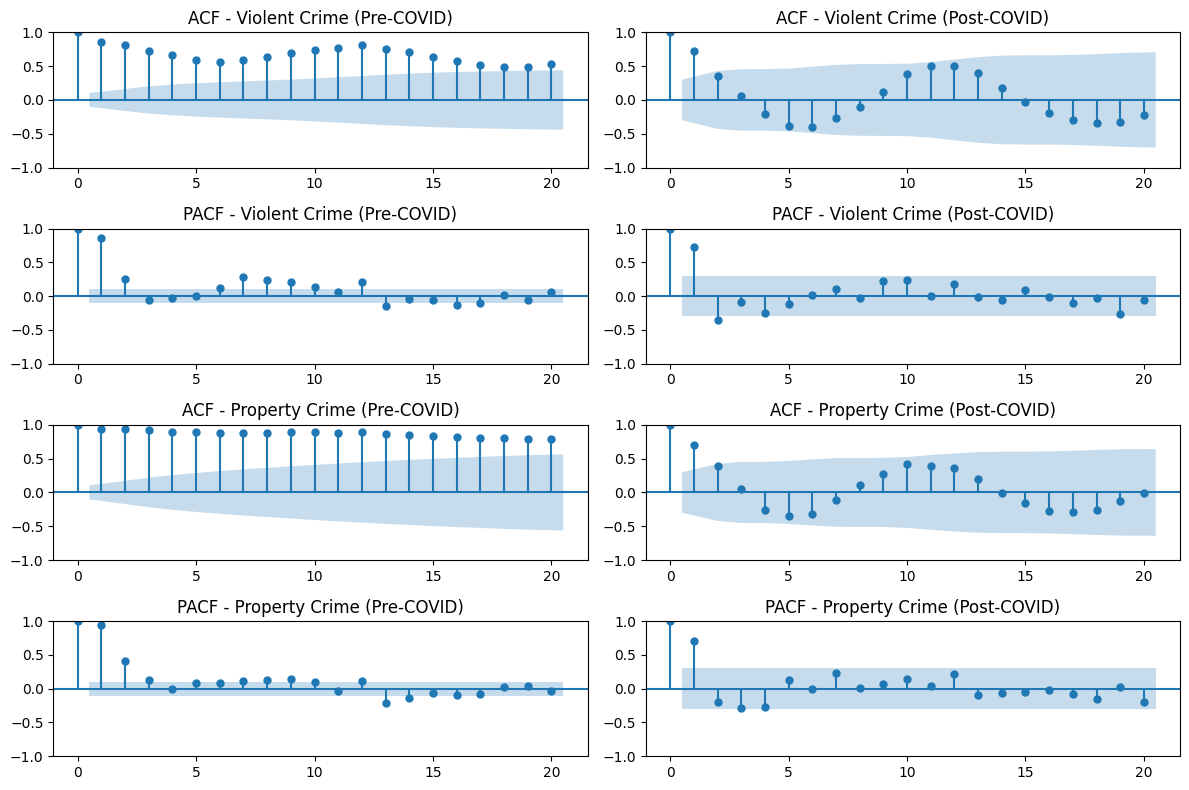

In [79]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

lags = 20  # smaller since splitting reduces sample size

crime_violent_pre = crime.loc[crime["Covid"] == 0, "Violent_Crime"]
crime__violent_post = crime.loc[crime["Covid"] == 2, "Violent_Crime"]

crime_property_pre = crime.loc[crime["Covid"] == 0, "Property_Crime"]
crime__property_post = crime.loc[crime["Covid"] == 2, "Property_Crime"]


fig, axes = plt.subplots(4, 2, figsize=(12, 8))

# ----------------- ACF for violent crime --------------
plot_acf(crime_violent_pre, lags=lags, ax=axes[0, 0])
axes[0, 0].set_title("ACF - Violent Crime (Pre-COVID)")

plot_acf(crime__violent_post, lags=lags, ax=axes[0, 1])
axes[0, 1].set_title("ACF - Violent Crime (Post-COVID)")

# ----------------- PACF for violent crime --------------
plot_pacf(crime_violent_pre, lags=lags, ax=axes[1, 0])
axes[1, 0].set_title("PACF - Violent Crime (Pre-COVID)")

plot_pacf(crime__violent_post, lags=lags, ax=axes[1, 1])
axes[1, 1].set_title("PACF - Violent Crime (Post-COVID)")



# ----------------- ACF for property crime --------------
plot_acf(crime_property_pre, lags=lags, ax=axes[2, 0])
axes[2, 0].set_title("ACF - Property Crime (Pre-COVID)")

plot_acf(crime__property_post, lags=lags, ax=axes[2, 1])
axes[2, 1].set_title("ACF - Property Crime (Post-COVID)")

# ----------------- PACF for property crime --------------
plot_pacf(crime_property_pre, lags=lags, ax=axes[3, 0])
axes[3, 0].set_title("PACF - Property Crime (Pre-COVID)")

plot_pacf(crime__property_post, lags=lags, ax=axes[3, 1])
axes[3, 1].set_title("PACF - Property Crime (Post-COVID)")





plt.tight_layout()

plt.savefig("ACF_Crime.jpg")

plt.show()



# move unemploymnet acf and pacf to supplementary 


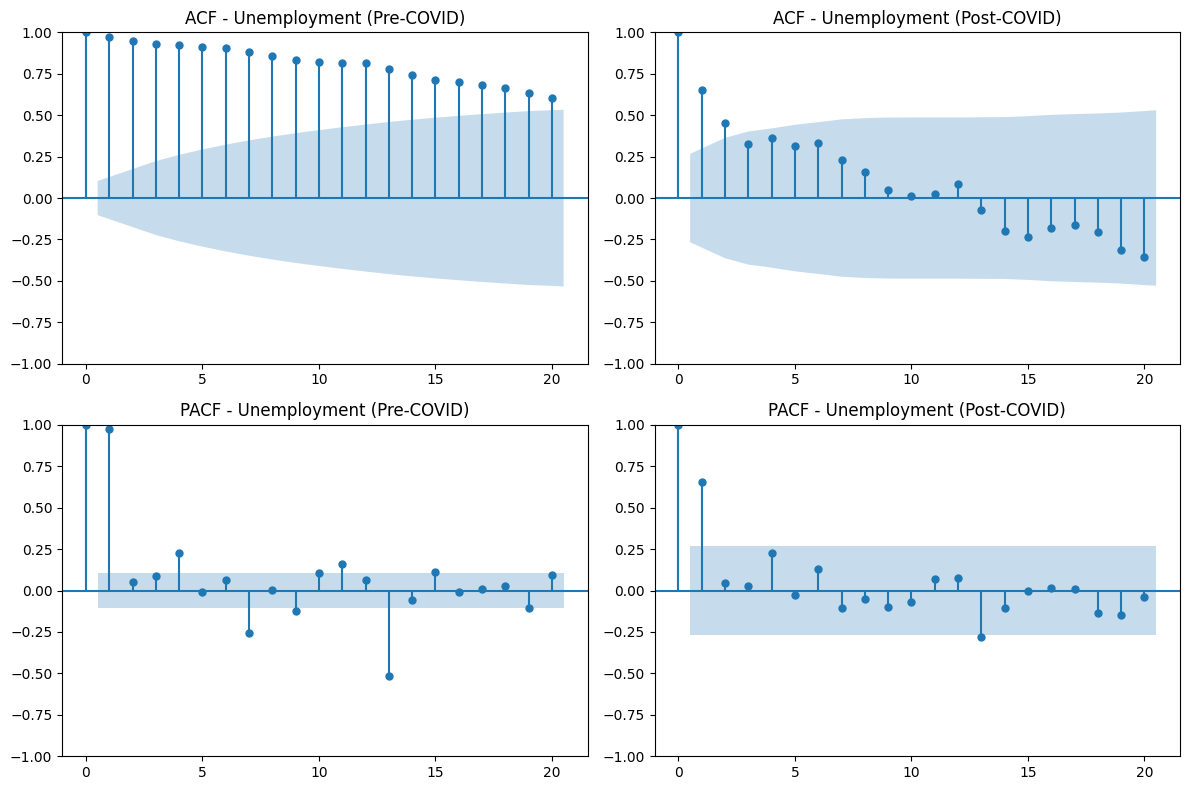

In [17]:
# Unemployment (To supplementary)


fig, axes = plt.subplots(2, 2, figsize=(12, 8))

unemp_pre = unemployment.loc[unemployment["Covid"] == 0, "Value"]
unemp_post = unemployment.loc[unemployment["Covid"] == 2, "Value"]


# --- ACF Row ---
plot_acf(unemp_pre, lags=lags, ax=axes[0, 0])
axes[0, 0].set_title("ACF - Unemployment (Pre-COVID)")

plot_acf(unemp_post, lags=lags, ax=axes[0, 1])
axes[0, 1].set_title("ACF - Unemployment (Post-COVID)")

# --- PACF Row ---
plot_pacf(unemp_pre, lags=lags, ax=axes[1, 0])
axes[1, 0].set_title("PACF - Unemployment (Pre-COVID)")

plot_pacf(unemp_post, lags=lags, ax=axes[1, 1])
axes[1, 1].set_title("PACF - Unemployment (Post-COVID)")

plt.tight_layout()
plt.show()




Professor was iffy on my results (taken out) of seasonal and first differencing in office hours. He also suggested into looking at detrending data.

We can do this in a SARIMAX model.

He liked using COVID as an exogenous variable



# Differencing (removed)

In [18]:
crime

,Date,Property_Crime,Violent_Crime,Covid,Value
60,1990-01-01,8829,2385,0,11214
61,1990-02-01,6991,1903,0,8894
62,1990-03-01,7860,2116,0,9976
63,1990-04-01,7648,2105,0,9753
64,1990-05-01,7281,2387,0,9668
...,...,...,...,...,...
487,2025-08-01,2456,1058,2,3514
488,2025-09-01,2065,920,2,2985
489,2025-10-01,2238,866,2,3104
490,2025-11-01,1986,814,2,2800


In [19]:

#professor was iffy on the prospect of differencing for our data. We only decided to do a log-transform of crime

import numpy as np

crime["log_Property"] = np.log1p(crime["Property_Crime"].values.astype(int))
crime["log_Violent"] = np.log1p(crime["Violent_Crime"].values.astype(int))



# commented out rest of differencing I tried.

#crime["Diff"] = (crime["log_value"].diff(12)) #seasonal then first


# unemployment I can just use first differencing since the ACF plot seems to depend on the immediate lag
#unemployment['Diff'] = unemployment['Value'].diff(1)



So now do I add a seasonal ma component to crime since like MA(1)? Since the lag spike is at 12?

What model would be best for unemployment since its just looking like a random walk?

We're trying to measure how 

# CCF

In [20]:
unemp_pre

0      9.1
1      9.2
2      8.9
3      8.4
4      8.6
      ... 
357    4.3
358    4.2
359    4.3
360    5.0
361    4.3
Name: Value, Length: 362, dtype: float64

In [21]:
from statsmodels.tsa.stattools import ccf


crime["Date"] = pd.to_datetime(crime["Date"]).dt.tz_localize(None)
unemployment["Date"] = pd.to_datetime(unemployment["Date"]).dt.tz_localize(None)


crime_pre = crime[crime["Covid"] == 0]
crime_post = crime[crime["Covid"] == 2]

unemp_pre = unemployment[unemployment["Covid"] == 0]
unemp_post = unemployment[unemployment["Covid"] == 2]



df_diff_pre = pd.merge(
    crime_pre[["Date", "log_Property", "log_Violent"]],
    unemp_pre[["Date", "Value"]],
    on="Date",
    how="inner"
)



df_diff_pre.columns = ["Date", "Property", "Violent", "Unemployment"]
df_diff_pre = df_diff_pre.dropna()

df_diff_pre






# post covid CCF
df_diff_post = pd.merge(
    crime_post[["Date", "log_Property", "log_Violent"]],
    unemp_post[["Date", "Value"]],
    on="Date",
    how="inner"
)

df_diff_post.columns = ["Date", "Property", "Violent", "Unemployment"]
df_diff_post = df_diff_post.dropna()
df_diff_pre


,Date,Property,Violent,Unemployment
0,1990-01-01,9.085910,7.777374,9.1
1,1990-02-01,8.852522,7.551712,9.2
2,1990-03-01,8.969669,7.657755,8.9
3,1990-04-01,8.942330,7.652546,8.4
4,1990-05-01,8.893161,7.778211,8.6
...,...,...,...,...
357,2019-10-01,7.904335,6.984716,4.3
358,2019-11-01,7.784057,6.851185,4.2
359,2019-12-01,7.862112,6.953684,4.3
360,2020-01-01,7.689371,6.852243,5.0


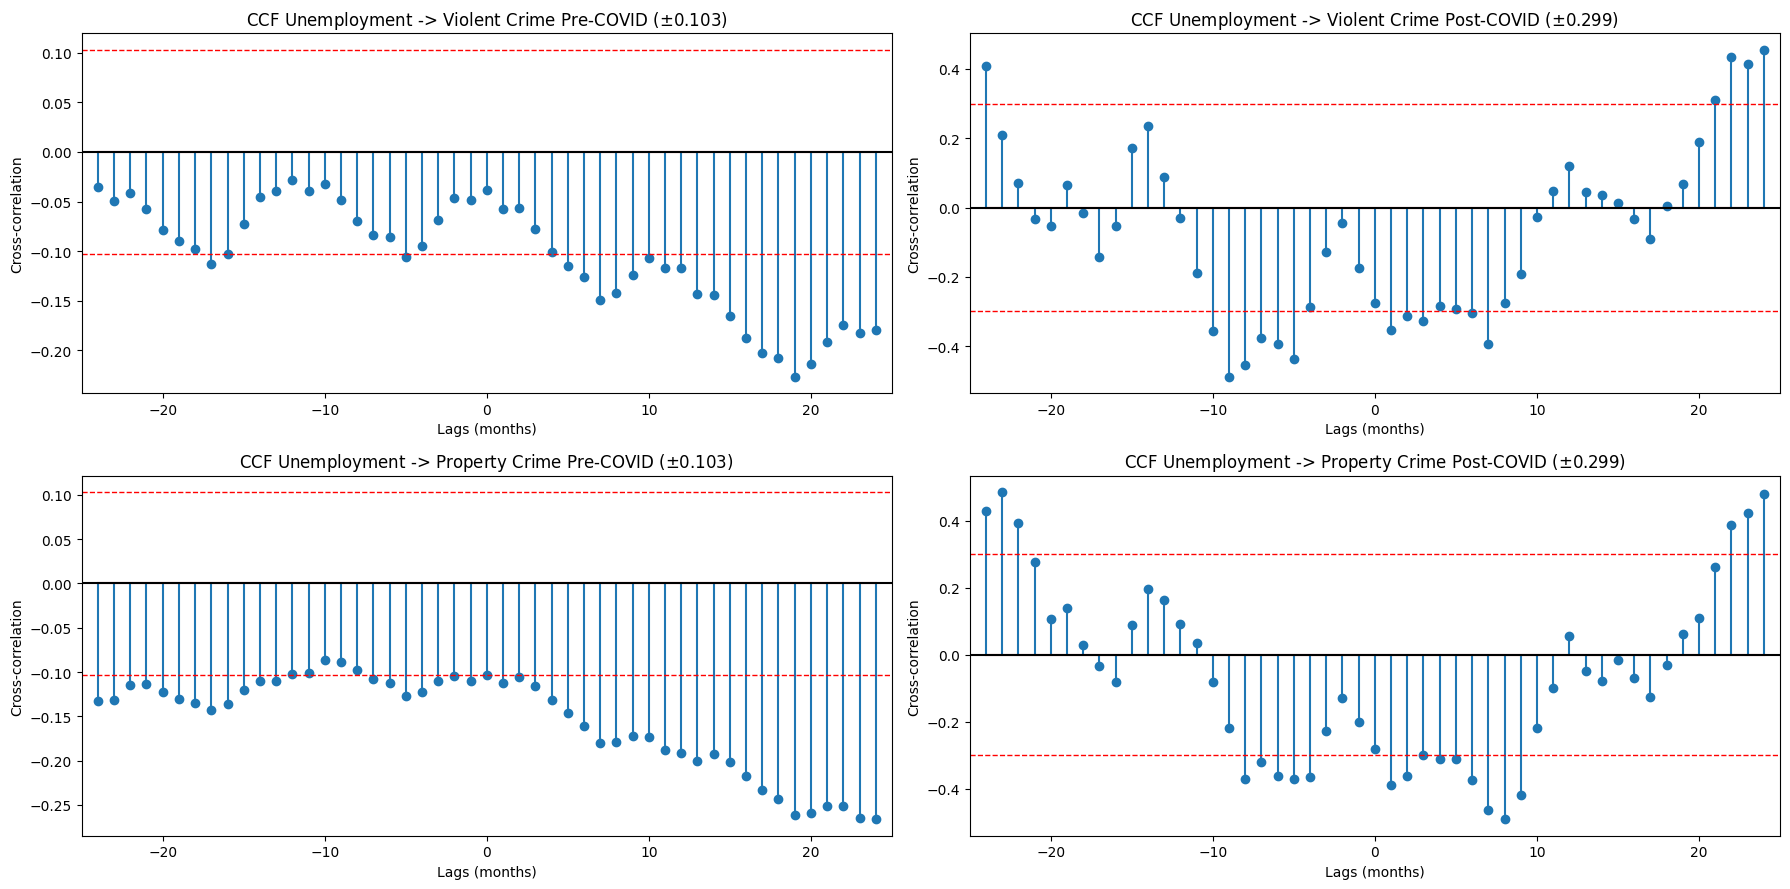

In [81]:

import numpy as np

def plot_ccf_symmetric(x, y, lags, ax, conf):
    # positive  valuesbetween x and y
    ccf_pos = ccf(x, y)[:lags+1]

    # negative values between y and x
    ccf_neg = ccf(y, x)[:lags+1]

    # remove repeat 0 in negative lag and reverse list, then concat the two
    ccf_full = np.concatenate((ccf_neg[1:][::-1], ccf_pos))

    lag_range = np.arange(-lags, lags+1)

    ax.stem(lag_range, ccf_full)
    ax.axhline(0, color="black")

    ax.axhline(conf, color="red", linestyle="--", linewidth=1)
    ax.axhline(-conf, color="red", linestyle="--", linewidth=1)
    ax.set_xlim(-lags-1, lags+1)
    ax.set_ylabel("Cross-correlation")
    ax.set_xlabel("Lags (months)")
    


lags = 24
fig, axes = plt.subplots(2, 2, figsize=(18, 9))

# pre covid CI
n_pre = len(df_diff_pre)
conf_pre = 1.96 / np.sqrt(n_pre)


# post covid CI
n_post = len(df_diff_post)
conf_post = 1.96 / np.sqrt(n_post)

# --------------- Violent Crime -------------------------

# Pre
plot_ccf_symmetric(
    df_diff_pre["Violent"].values,
    df_diff_pre["Unemployment"].values,
    lags,
    ax=axes[0,0],
    conf=conf_pre
)
axes[0,0].set_title(f"CCF Unemployment -> Violent Crime Pre-COVID ($\\pm${conf_pre:.3f})")




# post
plot_ccf_symmetric(
    df_diff_post["Violent"].values,
    df_diff_post["Unemployment"].values,
    lags,
    ax=axes[0,1],
    conf=conf_post
)
axes[0,1].set_title(f"CCF Unemployment -> Violent Crime Post-COVID ($\\pm${conf_post:.3f})")




# --------------- Property Crime ------------------------

# Pre
plot_ccf_symmetric(
    df_diff_pre["Property"].values,
    df_diff_pre["Unemployment"].values,
    lags,
    ax=axes[1,0],
    conf=conf_pre
)
axes[1,0].set_title(f"CCF Unemployment -> Property Crime Pre-COVID ($\\pm${conf_pre:.3f})")



# Post
plot_ccf_symmetric(
    df_diff_post["Property"].values,
    df_diff_post["Unemployment"].values,
    lags,
    ax=axes[1,1],
    conf=conf_post
)
axes[1,1].set_title(f"CCF Unemployment -> Property Crime Post-COVID ($\\pm${conf_post:.3f})")



plt.tight_layout()
plt.savefig("CCFs.jpg")

plt.show()




# Spectral Decomposition

In [58]:
crime_pre

,Date,Property_Crime,Violent_Crime,Covid,Value,log_Property,log_Violent,t
60,1990-01-01,8829,2385,0,11214,9.085910,7.777374,726468
61,1990-02-01,6991,1903,0,8894,8.852522,7.551712,726499
62,1990-03-01,7860,2116,0,9976,8.969669,7.657755,726527
63,1990-04-01,7648,2105,0,9753,8.942330,7.652546,726558
64,1990-05-01,7281,2387,0,9668,8.893161,7.778211,726588
...,...,...,...,...,...,...,...,...
417,2019-10-01,2708,1079,0,3787,7.904335,6.984716,737333
418,2019-11-01,2401,944,0,3345,7.784057,6.851185,737364
419,2019-12-01,2596,1046,0,3642,7.862112,6.953684,737394
420,2020-01-01,2184,945,0,3129,7.689371,6.852243,737425


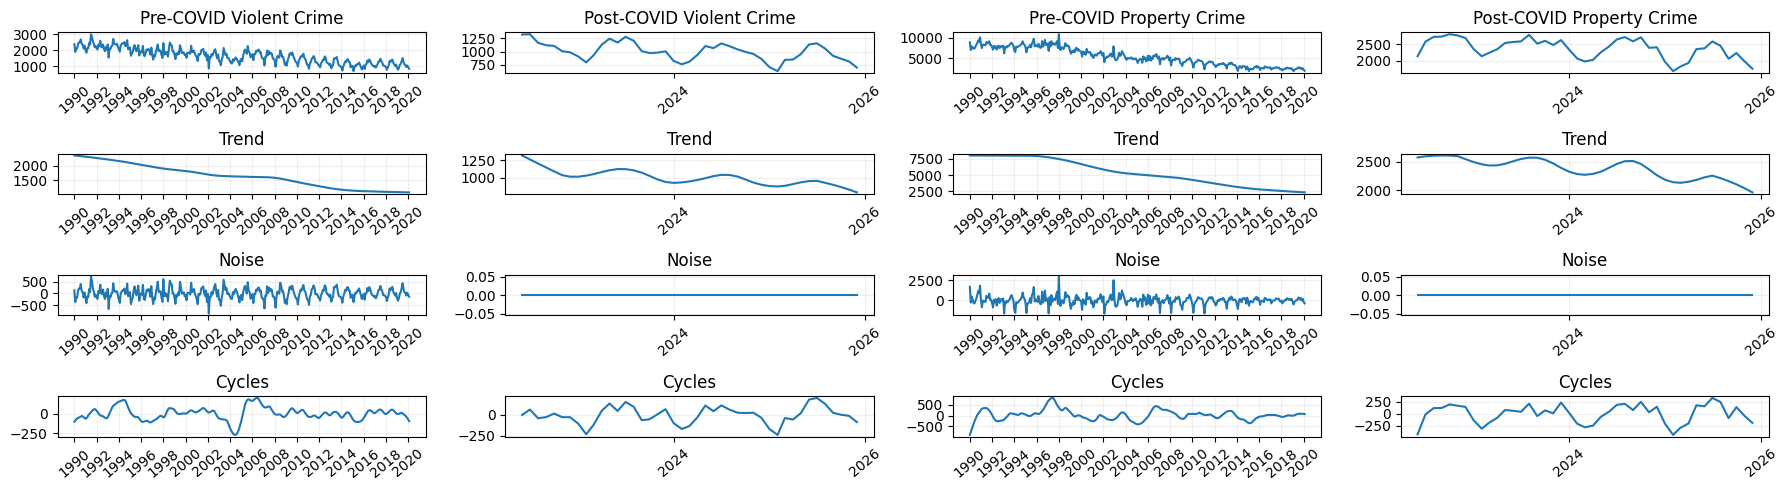

In [82]:
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.dates as mdates


# Used similar example from Ionides Lecture 8 slide 16 (trend, cycles, noise)
def decompose_series(y, x, frac_trend=0.3, frac_smooth=0.05):
    trend  = lowess(y, x, frac=frac_trend, return_sorted=False)
    smooth = lowess(y, x, frac=frac_smooth, return_sorted=False)
    cycles = smooth - trend
    noise  = y - smooth
    return trend, cycles, noise

# ----------------- Violent crime -----------------------------------

# --- clean pre/post data ---
crime_pre_v  = crime_pre.sort_values("Date").dropna(subset=["Date", "Violent_Crime"])
crime_post_v = crime_post.sort_values("Date").dropna(subset=["Date", "Violent_Crime"])

# convert date to numeric
x_pre  = crime_pre_v["Date"].map(pd.Timestamp.toordinal).to_numpy()
x_post = crime_post_v["Date"].map(pd.Timestamp.toordinal).to_numpy()

y_pre  = crime_pre_v["Violent_Crime"].to_numpy(dtype=float)
y_post = crime_post_v["Violent_Crime"].to_numpy(dtype=float)

trend_pre, cycles_pre, noise_pre     = decompose_series(y_pre, x_pre)
trend_post, cycles_post, noise_post  = decompose_series(y_post, x_post)

fig, axes = plt.subplots(4, 4, figsize=(18, 5), sharex=False)

# Pre
axes[0,0].plot(crime_pre_v["Date"], y_pre);       axes[0,0].set_title("Pre-COVID Violent Crime")
axes[1,0].plot(crime_pre_v["Date"], trend_pre);   axes[1,0].set_title("Trend")
axes[2,0].plot(crime_pre_v["Date"], noise_pre);   axes[2,0].set_title("Noise")
axes[3,0].plot(crime_pre_v["Date"], cycles_pre);  axes[3,0].set_title("Cycles")

# Post
axes[0,1].plot(crime_post_v["Date"], y_post);       axes[0,1].set_title("Post-COVID Violent Crime")
axes[1,1].plot(crime_post_v["Date"], trend_post);   axes[1,1].set_title("Trend")
axes[2,1].plot(crime_post_v["Date"], noise_post);   axes[2,1].set_title("Noise")
axes[3,1].plot(crime_post_v["Date"], cycles_post);  axes[3,1].set_title("Cycles")

for ax in axes.flatten():
    ax.grid(alpha=0.2)



# ----------------- Property Crime -----------------------------------



crime_pre_p  = crime_pre.sort_values("Date").dropna(subset=["Date", "Property_Crime"])
crime_post_p = crime_post.sort_values("Date").dropna(subset=["Date", "Property_Crime"])

x_pre  = crime_pre_p["Date"].map(pd.Timestamp.toordinal).to_numpy()
x_post = crime_post_p["Date"].map(pd.Timestamp.toordinal).to_numpy()

y_pre  = crime_pre_p["Property_Crime"].to_numpy(dtype=float)
y_post = crime_post_p["Property_Crime"].to_numpy(dtype=float)

trend_pre, cycles_pre, noise_pre     = decompose_series(y_pre, x_pre)
trend_post, cycles_post, noise_post  = decompose_series(y_post, x_post)


# Pre
axes[0,2].plot(crime_pre_p["Date"], y_pre);       axes[0,2].set_title("Pre-COVID Property Crime")
axes[1,2].plot(crime_pre_p["Date"], trend_pre);   axes[1,2].set_title("Trend")
axes[2,2].plot(crime_pre_p["Date"], noise_pre);   axes[2,2].set_title("Noise")
axes[3,2].plot(crime_pre_p["Date"], cycles_pre);  axes[3,2].set_title("Cycles")

# Post
axes[0,3].plot(crime_post_p["Date"], y_post);       axes[0,3].set_title("Post-COVID Property Crime")
axes[1,3].plot(crime_post_p["Date"], trend_post);   axes[1,3].set_title("Trend")
axes[2,3].plot(crime_post_p["Date"], noise_post);   axes[2,3].set_title("Noise")
axes[3,3].plot(crime_post_p["Date"], cycles_post);  axes[3,3].set_title("Cycles")


# Here, I Googled "ways to edit the dates on the x-axis via matplotlib". Google AI popped up and recommended using the DateFormatter 

for ax in axes.flatten():
    ax.xaxis.set_major_locator(mdates.YearLocator(base=2))   # change up dates on x-axis because they were overlapping
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", labelrotation=40)

plt.tight_layout()
plt.savefig("spectral_decomp.jpg")

plt.show()